In [5]:
# import libraries 
import pandas as pd
import numpy as np
from dateutil import parser
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

PART 2 - Python: Exploratory Data Analysis
Using Python (Pandas, Matplotlib/Seaborn), you will merge some extracted SQL datasets into a single, consistent analytical dataset, then perform exploratory analysis on the unified dataset.

Data Integration & Modeling
Load all exported SQL CSV files into Pandas.


Inspect each dataset and identify:


Primary keys (e.g., film_id, customer_id, store_id, staff_id, date/month).


Foreign keys and shared columns.


Clean column names and data types (dates, currency, categorical values).


Merge all datasets into one master dataset if possible that includes:


Film attributes


Customer attributes


Store and staff attributes


Geographic attributes


Time attributes


Revenue and rental metrics


The final dataset should allow filtering by:
Date/month


Film, category


Customer


Store, staff


Country, city


In [6]:
# Load a csv file on pandas
#Load csv file dataset on pandas 

revenue = pd.read_csv("data/revenue_film_performance.csv")

revenue

,film_id,film_title,category,total_rental_revenue,total_number_of_rentals,average_revenue_per_rental,last_rental_date
0,879,Telegraph Voyage,Music,215.75,25,8.63,2005-08-23 08:27:57
1,1000,Zorro Ark,Comedy,199.72,28,7.13,2005-08-23 17:56:01
2,973,Wife Turn,Documentary,198.73,27,7.36,2005-08-23 14:47:26
3,460,Innocent Usual,Foreign,191.74,26,7.37,2005-08-22 15:22:15
4,444,Hustler Party,Comedy,190.78,22,8.67,2005-08-23 09:42:21
...,...,...,...,...,...,...,...
953,996,Young Language,Documentary,6.93,7,0.99,2005-08-23 01:50:31
954,335,Freedom Cleopatra,Comedy,5.95,5,1.19,2005-08-21 12:48:08
955,261,Duffel Apocalypse,Documentary,5.94,6,0.99,2005-08-21 00:21:29
956,635,Oklahoma Jumanji,New,5.94,6,0.99,2005-08-23 03:44:30


In [7]:
# Load a csv file on pandas
#Load csv file dataset on pandas 

customer = pd.read_csv("data/customer_behavior_retention.csv")

customer

,store_id,customer_id,full_name,country,city,total_amount_spent,total_rentals,first_rental_date,most_recent_rental_date,number_of_rental_months
0,1,148,Eleanor Hunt,Runion,Saint-Denis,211.55,45,2005-06-15 22:02:35,2005-08-23 05:57:04,3
1,2,526,Karl Seal,United States,Cape Coral,208.58,42,2005-06-15 06:13:45,2005-08-23 22:21:03,3
2,2,178,Marion Snyder,Brazil,Santa Brbara dOeste,194.61,39,2005-06-15 09:03:52,2006-02-14 15:16:03,4
3,2,137,Rhonda Kennedy,Netherlands,Apeldoorn,191.62,38,2005-06-18 20:24:23,2005-08-23 21:56:04,3
4,1,144,Clara Shaw,Belarus,Molodetno,189.60,40,2005-06-16 21:15:22,2005-08-23 12:43:30,3
...,...,...,...,...,...,...,...,...,...,...
594,2,110,Tiffany Jordan,China,Enshi,49.88,12,2005-06-16 00:32:52,2005-08-22 22:28:36,3
595,2,320,Anthony Schwab,American Samoa,Tafuna,47.85,15,2005-07-06 00:57:29,2005-08-22 19:44:53,2
596,1,248,Caroline Bowman,United States,Tallahassee,37.87,13,2005-06-17 16:07:08,2005-08-22 03:58:29,3
597,2,281,Leona Obrien,China,Fuzhou,32.90,10,2005-07-08 07:15:14,2005-08-21 03:40:40,2


In [8]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   store_id                 599 non-null    int64  
 1   customer_id              599 non-null    int64  
 2   full_name                599 non-null    str    
 3   country                  599 non-null    str    
 4   city                     599 non-null    str    
 5   total_amount_spent       599 non-null    float64
 6   total_rentals            599 non-null    int64  
 7   first_rental_date        599 non-null    str    
 8   most_recent_rental_date  599 non-null    str    
 9   number_of_rental_months  599 non-null    int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 86.3 KB


In [9]:
# change first_rental_date column from str to date datatype 

customer['first_rental_date'] = pd.to_datetime(customer['first_rental_date'], errors="coerce")

customer['first_rental_date']

0     2005-06-15 22:02:35
1     2005-06-15 06:13:45
2     2005-06-15 09:03:52
3     2005-06-18 20:24:23
4     2005-06-16 21:15:22
              ...        
594   2005-06-16 00:32:52
595   2005-07-06 00:57:29
596   2005-06-17 16:07:08
597   2005-07-08 07:15:14
598   2005-07-06 11:33:37
Name: first_rental_date, Length: 599, dtype: datetime64[us]

In [10]:
# change most_recent_rental_date column from str to date datatype 

customer['most_recent_rental_date'] = pd.to_datetime(customer['most_recent_rental_date'], errors="coerce")

customer['most_recent_rental_date']

0     2005-08-23 05:57:04
1     2005-08-23 22:21:03
2     2006-02-14 15:16:03
3     2005-08-23 21:56:04
4     2005-08-23 12:43:30
              ...        
594   2005-08-22 22:28:36
595   2005-08-22 19:44:53
596   2005-08-22 03:58:29
597   2005-08-21 03:40:40
598   2005-08-21 06:34:05
Name: most_recent_rental_date, Length: 599, dtype: datetime64[us]

In [11]:
customer.shape

(599, 10)

In [12]:
customer.columns

Index(['store_id', 'customer_id', 'full_name', 'country', 'city',
       'total_amount_spent', 'total_rentals', 'first_rental_date',
       'most_recent_rental_date', 'number_of_rental_months'],
      dtype='str')

In [13]:
# Standadize all columns in customer dataset
customer.rename(columns={
    'store_id' : 'Store ID' ,
    'customer_id' : 'Customer ID' ,
    'full_name' : 'Full Name' ,
    'country' : 'Country' ,
    'city' : 'City' ,
    'total_amount_spent' : 'Total Amount Spent' ,
    'total_rentals' : 'Total Rentals' ,
    'first_rental_date' : 'First Rental Date' ,
    'most_recent_rental_date' : 'Most Recent Rental Date' ,
    'number_of_rental_months' : 'Number Of Rental Months'
   
} , inplace=True)

customer

,Store ID,Customer ID,Full Name,Country,City,Total Amount Spent,Total Rentals,First Rental Date,Most Recent Rental Date,Number Of Rental Months
0,1,148,Eleanor Hunt,Runion,Saint-Denis,211.55,45,2005-06-15 22:02:35,2005-08-23 05:57:04,3
1,2,526,Karl Seal,United States,Cape Coral,208.58,42,2005-06-15 06:13:45,2005-08-23 22:21:03,3
2,2,178,Marion Snyder,Brazil,Santa Brbara dOeste,194.61,39,2005-06-15 09:03:52,2006-02-14 15:16:03,4
3,2,137,Rhonda Kennedy,Netherlands,Apeldoorn,191.62,38,2005-06-18 20:24:23,2005-08-23 21:56:04,3
4,1,144,Clara Shaw,Belarus,Molodetno,189.60,40,2005-06-16 21:15:22,2005-08-23 12:43:30,3
...,...,...,...,...,...,...,...,...,...,...
594,2,110,Tiffany Jordan,China,Enshi,49.88,12,2005-06-16 00:32:52,2005-08-22 22:28:36,3
595,2,320,Anthony Schwab,American Samoa,Tafuna,47.85,15,2005-07-06 00:57:29,2005-08-22 19:44:53,2
596,1,248,Caroline Bowman,United States,Tallahassee,37.87,13,2005-06-17 16:07:08,2005-08-22 03:58:29,3
597,2,281,Leona Obrien,China,Fuzhou,32.90,10,2005-07-08 07:15:14,2005-08-21 03:40:40,2


In [14]:
# Load a csv file on pandas
#Load csv file dataset on pandas 

time = pd.read_csv("data/time_based_business_trends.csv")

time

,customer_id,inventory_id,rental_month,rental_id,total_revenue,average_revenue_per_rental
0,1,14,2005-08-01,1,4.99,4.99
1,1,108,2005-07-01,1,2.99,2.99
2,1,197,2005-06-01,1,4.99,4.99
3,1,312,2005-08-01,1,5.99,5.99
4,1,726,2005-06-01,1,4.99,4.99
...,...,...,...,...,...,...
14587,599,3819,2005-07-01,1,2.99,2.99
14588,599,3990,2005-08-01,1,2.99,2.99
14589,599,4048,2005-08-01,1,8.99,8.99
14590,599,4091,2005-08-01,1,1.99,1.99


In [15]:
time.info()

<class 'pandas.DataFrame'>
RangeIndex: 14592 entries, 0 to 14591
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 14592 non-null  int64  
 1   inventory_id                14592 non-null  int64  
 2   rental_month                14592 non-null  str    
 3   rental_id                   14592 non-null  int64  
 4   total_revenue               14592 non-null  float64
 5   average_revenue_per_rental  14592 non-null  float64
dtypes: float64(2), int64(3), str(1)
memory usage: 826.6 KB


In [16]:
# change rental_month column from str to date datatype 

time['rental_month'] = pd.to_datetime(time['rental_month'], errors="coerce")

time['rental_month']

0       2005-08-01
1       2005-07-01
2       2005-06-01
3       2005-08-01
4       2005-06-01
           ...    
14587   2005-07-01
14588   2005-08-01
14589   2005-08-01
14590   2005-08-01
14591   2005-08-01
Name: rental_month, Length: 14592, dtype: datetime64[us]

In [17]:
time.shape

(14592, 6)

In [18]:
time.columns

Index(['customer_id', 'inventory_id', 'rental_month', 'rental_id',
       'total_revenue', 'average_revenue_per_rental'],
      dtype='str')

In [19]:
# Standadize all columns in time dataset
time.rename(columns={
    "customer_id" : "Customer ID" , 
    "inventory_id" : "Film ID" ,
    "rental_month" : "Film Title" ,
    "rental_id" : "Category" ,
    "total_revenue" : "Inventory Count" ,
    "average_revenue_per_rental" : "Total Rentals" 

} , inplace=True)

time


,Customer ID,Film ID,Film Title,Category,Inventory Count,Total Rentals
0,1,14,2005-08-01,1,4.99,4.99
1,1,108,2005-07-01,1,2.99,2.99
2,1,197,2005-06-01,1,4.99,4.99
3,1,312,2005-08-01,1,5.99,5.99
4,1,726,2005-06-01,1,4.99,4.99
...,...,...,...,...,...,...
14587,599,3819,2005-07-01,1,2.99,2.99
14588,599,3990,2005-08-01,1,2.99,2.99
14589,599,4048,2005-08-01,1,8.99,8.99
14590,599,4091,2005-08-01,1,1.99,1.99


In [20]:
# Load a csv file on pandas
#Load csv file dataset on pandas 

store = pd.read_csv("data/store_staff_performance.csv")

store

,store_id,staff_id,staff_name,total_rentals_processed,total_revenue_collected,number_of_unique_customers_served,average_rentals_per_day
0,1,1,Mike Hillyer,7292,30252.12,599,220.97
1,2,2,Jon Stephens,7304,31059.92,599,221.33


In [21]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   store_id                           2 non-null      int64  
 1   staff_id                           2 non-null      int64  
 2   staff_name                         2 non-null      str    
 3   total_rentals_processed            2 non-null      int64  
 4   total_revenue_collected            2 non-null      float64
 5   number_of_unique_customers_served  2 non-null      int64  
 6   average_rentals_per_day            2 non-null      float64
dtypes: float64(2), int64(4), str(1)
memory usage: 268.0 bytes


In [22]:
store.shape

(2, 7)

In [23]:
store.columns

Index(['store_id', 'staff_id', 'staff_name', 'total_rentals_processed',
       'total_revenue_collected', 'number_of_unique_customers_served',
       'average_rentals_per_day'],
      dtype='str')

In [24]:
# Standadize all columns in store dataset
store.rename(columns={
    
    'store_id' : 'Store ID' ,
    'staff_id' : 'Staff ID' ,
    'staff_name' : 'Staff Name' ,
    'total_rentals_processed' : 'Total Rentals Processed' ,
    'total_revenue_collected' : 'Total Revenue Collected' ,
    'number_of_unique_customers_served' : 'Number Of Unique Customers Served' ,
    'average_rentals_per_day' : 'Average Rentals Per Day'
    
} , inplace=True)

store

,Store ID,Staff ID,Staff Name,Total Rentals Processed,Total Revenue Collected,Number Of Unique Customers Served,Average Rentals Per Day
0,1,1,Mike Hillyer,7292,30252.12,599,220.97
1,2,2,Jon Stephens,7304,31059.92,599,221.33


In [25]:
# Load a csv file on pandas
#Load csv file dataset on pandas 

geographic = pd.read_csv("data/geographic_market_analysis.csv")

geographic

,country,city,total_rentals,total_revenue,number_of_unique_customers,most_popular_film_category
0,Runion,Saint-Denis,46,211.55,1,Sci-Fi
1,United States,Cape Coral,45,208.58,1,Animation
2,Brazil,Santa Brbara dOeste,39,194.61,1,Drama
3,Netherlands,Apeldoorn,39,191.62,1,Games
4,Belarus,Molodetno,42,189.60,1,Drama
...,...,...,...,...,...,...
592,China,Enshi,14,49.88,1,Drama
593,American Samoa,Tafuna,20,47.85,1,Sports
594,United States,Tallahassee,15,37.87,1,Sci-Fi
595,China,Fuzhou,14,32.90,1,Family


In [26]:
inventory = pd.read_csv("data/inventory_operations.csv")

inventory

,store_id,film_id,film_title,category,inventory_count,total_rentals,total_revenue,last_rental_date,average_rental_duration
0,1.0,1,Academy Dinosaur,Documentary,4,12,18.89,2005-08-23 01:01:01,4.58
1,2.0,1,Academy Dinosaur,Documentary,4,11,14.90,2005-08-22 00:44:08,4.50
2,2.0,2,Ace Goldfinger,Horror,3,7,52.93,2006-02-14 15:16:03,5.33
3,2.0,3,Adaptation Holes,Documentary,4,12,34.89,2005-08-23 13:54:39,2.83
4,1.0,4,Affair Prejudice,Horror,4,13,49.88,2005-08-22 21:16:54,4.62
...,...,...,...,...,...,...,...,...,...
1558,2.0,998,Zhivago Core,Horror,2,9,10.93,2006-02-14 15:16:03,5.25
1559,1.0,999,Zoolander Fiction,Children,2,6,23.94,2005-08-21 22:41:56,5.33
1560,2.0,999,Zoolander Fiction,Children,3,11,42.91,2005-08-23 08:48:43,5.09
1561,1.0,1000,Zorro Ark,Comedy,4,16,108.85,2005-08-21 17:43:42,4.44


In [27]:
M1 = pd.merge(
    inventory, revenue,
    on=["film_id", "film_title", "category", "last_rental_date"],
    how="inner",
)
M1

,store_id,film_id,film_title,category,inventory_count,total_rentals,total_revenue,last_rental_date,average_rental_duration,total_rental_revenue,total_number_of_rentals,average_revenue_per_rental
0,1.0,1,Academy Dinosaur,Documentary,4,12,18.89,2005-08-23 01:01:01,4.58,33.79,21,1.61
1,2.0,2,Ace Goldfinger,Horror,3,7,52.93,2006-02-14 15:16:03,5.33,52.93,7,7.56
2,2.0,3,Adaptation Holes,Documentary,4,12,34.89,2005-08-23 13:54:39,2.83,34.89,11,3.17
3,2.0,4,Affair Prejudice,Horror,3,10,33.91,2006-02-14 15:16:03,4.00,83.79,21,3.99
4,2.0,5,African Egg,Family,3,12,47.89,2006-02-14 15:16:03,6.73,47.89,11,4.35
...,...,...,...,...,...,...,...,...,...,...,...,...
960,1.0,996,Young Language,Documentary,2,7,6.93,2005-08-23 01:50:31,4.00,6.93,7,0.99
961,1.0,997,Youth Kick,Music,2,6,16.94,2005-08-18 17:31:36,4.67,16.94,6,2.82
962,2.0,998,Zhivago Core,Horror,2,9,10.93,2006-02-14 15:16:03,5.25,10.93,7,1.56
963,2.0,999,Zoolander Fiction,Children,3,11,42.91,2005-08-23 08:48:43,5.09,66.85,15,4.46


In [28]:
M1.info()

<class 'pandas.DataFrame'>
RangeIndex: 965 entries, 0 to 964
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   store_id                    965 non-null    float64
 1   film_id                     965 non-null    int64  
 2   film_title                  965 non-null    str    
 3   category                    965 non-null    str    
 4   inventory_count             965 non-null    int64  
 5   total_rentals               965 non-null    int64  
 6   total_revenue               965 non-null    float64
 7   last_rental_date            965 non-null    str    
 8   average_rental_duration     965 non-null    float64
 9   total_rental_revenue        965 non-null    float64
 10  total_number_of_rentals     965 non-null    int64  
 11  average_revenue_per_rental  965 non-null    float64
dtypes: float64(5), int64(4), str(3)
memory usage: 128.4 KB


In [29]:
# change last_rental_date column to date datatype 

M1['last_rental_date'] = pd.to_datetime(M1['last_rental_date'], errors="coerce")

M1['last_rental_date']

0     2005-08-23 01:01:01
1     2006-02-14 15:16:03
2     2005-08-23 13:54:39
3     2006-02-14 15:16:03
4     2006-02-14 15:16:03
              ...        
960   2005-08-23 01:50:31
961   2005-08-18 17:31:36
962   2006-02-14 15:16:03
963   2005-08-23 08:48:43
964   2005-08-23 17:56:01
Name: last_rental_date, Length: 965, dtype: datetime64[us]

In [30]:
M1.dtypes

store_id                             float64
film_id                                int64
film_title                               str
category                                 str
inventory_count                        int64
total_rentals                          int64
total_revenue                        float64
last_rental_date              datetime64[us]
average_rental_duration              float64
total_rental_revenue                 float64
total_number_of_rentals                int64
average_revenue_per_rental           float64
dtype: object

In [31]:
M1.shape

(965, 12)

In [32]:
M1.columns

Index(['store_id', 'film_id', 'film_title', 'category', 'inventory_count',
       'total_rentals', 'total_revenue', 'last_rental_date',
       'average_rental_duration', 'total_rental_revenue',
       'total_number_of_rentals', 'average_revenue_per_rental'],
      dtype='str')

In [33]:
# Standadize M1 columns
M1.rename(columns={
    "store_id" : "Store ID" , 
    "film_id" : "Film ID" ,
    "film_title" : "Film Title" ,
    "category" : "Category" ,
    "inventory_count" : "Inventory Count" ,
    "total_rentals" : "Total Rentals" ,
    "total_revenue" : "Total Revenue" ,
    "last_rental_date" : "Last Rental Date" ,
    "average_rental_duration" : "Average Rental Duration" ,
    "total_rental_duration" : "Total Rental Duration" ,
    "total_number_of_rentals" : "Total Number of Rentals" ,
    "average_revenue_per_rental" : "Average Revenue Per Rental" 

} , inplace=True)

M1



,Store ID,Film ID,Film Title,Category,Inventory Count,Total Rentals,Total Revenue,Last Rental Date,Average Rental Duration,total_rental_revenue,Total Number of Rentals,Average Revenue Per Rental
0,1.0,1,Academy Dinosaur,Documentary,4,12,18.89,2005-08-23 01:01:01,4.58,33.79,21,1.61
1,2.0,2,Ace Goldfinger,Horror,3,7,52.93,2006-02-14 15:16:03,5.33,52.93,7,7.56
2,2.0,3,Adaptation Holes,Documentary,4,12,34.89,2005-08-23 13:54:39,2.83,34.89,11,3.17
3,2.0,4,Affair Prejudice,Horror,3,10,33.91,2006-02-14 15:16:03,4.00,83.79,21,3.99
4,2.0,5,African Egg,Family,3,12,47.89,2006-02-14 15:16:03,6.73,47.89,11,4.35
...,...,...,...,...,...,...,...,...,...,...,...,...
960,1.0,996,Young Language,Documentary,2,7,6.93,2005-08-23 01:50:31,4.00,6.93,7,0.99
961,1.0,997,Youth Kick,Music,2,6,16.94,2005-08-18 17:31:36,4.67,16.94,6,2.82
962,2.0,998,Zhivago Core,Horror,2,9,10.93,2006-02-14 15:16:03,5.25,10.93,7,1.56
963,2.0,999,Zoolander Fiction,Children,3,11,42.91,2005-08-23 08:48:43,5.09,66.85,15,4.46


In [34]:
M2 = pd.merge(
    store,
    customer,
    on=["Store ID"],
    how="inner",
)
M2

,Store ID,Staff ID,Staff Name,Total Rentals Processed,Total Revenue Collected,Number Of Unique Customers Served,Average Rentals Per Day,Customer ID,Full Name,Country,City,Total Amount Spent,Total Rentals,First Rental Date,Most Recent Rental Date,Number Of Rental Months
0,1,1,Mike Hillyer,7292,30252.12,599,220.97,148,Eleanor Hunt,Runion,Saint-Denis,211.55,45,2005-06-15 22:02:35,2005-08-23 05:57:04,3
1,1,1,Mike Hillyer,7292,30252.12,599,220.97,144,Clara Shaw,Belarus,Molodetno,189.60,40,2005-06-16 21:15:22,2005-08-23 12:43:30,3
2,1,1,Mike Hillyer,7292,30252.12,599,220.97,459,Tommy Collazo,Iran,Qomsheh,183.63,37,2005-06-17 02:50:51,2005-08-23 14:52:50,3
3,1,1,Mike Hillyer,7292,30252.12,599,220.97,236,Marcia Dean,Philippines,Tanza,166.61,39,2005-06-15 06:54:53,2006-02-14 15:16:03,4
4,1,1,Mike Hillyer,7292,30252.12,599,220.97,403,Mike Way,India,Valparai,162.67,33,2005-06-15 03:35:16,2005-08-22 23:27:43,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,2,2,Jon Stephens,7304,31059.92,599,221.33,395,Johnny Turpin,Sudan,al-Qadarif,57.81,19,2005-06-15 07:30:22,2005-08-23 19:54:24,3
595,2,2,Jon Stephens,7304,31059.92,599,221.33,250,Jo Fowler,Nigeria,Oyo,54.85,15,2005-06-18 17:59:18,2005-08-22 17:52:05,3
596,2,2,Jon Stephens,7304,31059.92,599,221.33,110,Tiffany Jordan,China,Enshi,49.88,12,2005-06-16 00:32:52,2005-08-22 22:28:36,3
597,2,2,Jon Stephens,7304,31059.92,599,221.33,320,Anthony Schwab,American Samoa,Tafuna,47.85,15,2005-07-06 00:57:29,2005-08-22 19:44:53,2


In [35]:
M2.info()

<class 'pandas.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Store ID                           599 non-null    int64         
 1   Staff ID                           599 non-null    int64         
 2   Staff Name                         599 non-null    str           
 3   Total Rentals Processed            599 non-null    int64         
 4   Total Revenue Collected            599 non-null    float64       
 5   Number Of Unique Customers Served  599 non-null    int64         
 6   Average Rentals Per Day            599 non-null    float64       
 7   Customer ID                        599 non-null    int64         
 8   Full Name                          599 non-null    str           
 9   Country                            599 non-null    str           
 10  City                               599 non-null  

In [36]:
M2.dtypes

Store ID                                      int64
Staff ID                                      int64
Staff Name                                      str
Total Rentals Processed                       int64
Total Revenue Collected                     float64
Number Of Unique Customers Served             int64
Average Rentals Per Day                     float64
Customer ID                                   int64
Full Name                                       str
Country                                         str
City                                            str
Total Amount Spent                          float64
Total Rentals                                 int64
First Rental Date                    datetime64[us]
Most Recent Rental Date              datetime64[us]
Number Of Rental Months                       int64
dtype: object

In [37]:
# change first_rental_date column from str to date datatype 

M2['First Rental Date'] = pd.to_datetime(M2['First Rental Date'], errors="coerce")

M2['First Rental Date']

0     2005-06-15 22:02:35
1     2005-06-16 21:15:22
2     2005-06-17 02:50:51
3     2005-06-15 06:54:53
4     2005-06-15 03:35:16
              ...        
594   2005-06-15 07:30:22
595   2005-06-18 17:59:18
596   2005-06-16 00:32:52
597   2005-07-06 00:57:29
598   2005-07-08 07:15:14
Name: First Rental Date, Length: 599, dtype: datetime64[us]

In [38]:
# change most_recent_rental_date column from str to date datatype 

M2['Most Recent Rental Date'] = pd.to_datetime(M2['Most Recent Rental Date'], errors="coerce")

M2['Most Recent Rental Date']

0     2005-08-23 05:57:04
1     2005-08-23 12:43:30
2     2005-08-23 14:52:50
3     2006-02-14 15:16:03
4     2005-08-22 23:27:43
              ...        
594   2005-08-23 19:54:24
595   2005-08-22 17:52:05
596   2005-08-22 22:28:36
597   2005-08-22 19:44:53
598   2005-08-21 03:40:40
Name: Most Recent Rental Date, Length: 599, dtype: datetime64[us]

In [39]:
M2.info()

<class 'pandas.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Store ID                           599 non-null    int64         
 1   Staff ID                           599 non-null    int64         
 2   Staff Name                         599 non-null    str           
 3   Total Rentals Processed            599 non-null    int64         
 4   Total Revenue Collected            599 non-null    float64       
 5   Number Of Unique Customers Served  599 non-null    int64         
 6   Average Rentals Per Day            599 non-null    float64       
 7   Customer ID                        599 non-null    int64         
 8   Full Name                          599 non-null    str           
 9   Country                            599 non-null    str           
 10  City                               599 non-null  

In [40]:
M2.columns

Index(['Store ID', 'Staff ID', 'Staff Name', 'Total Rentals Processed',
       'Total Revenue Collected', 'Number Of Unique Customers Served',
       'Average Rentals Per Day', 'Customer ID', 'Full Name', 'Country',
       'City', 'Total Amount Spent', 'Total Rentals', 'First Rental Date',
       'Most Recent Rental Date', 'Number Of Rental Months'],
      dtype='str')

In [41]:
M2.shape

(599, 16)

In [42]:
# Standadize M2 columns
M2.rename(columns={
    "store_id" : "Store ID" , 
    "staff_id" : "Staff ID" ,
    "staff_name" : "Staff Name" ,
    "total_rentals_processed" : "Total Rentals Processed" ,
    "total_revenue_collected" : "Total Revenue Collected" ,
    "number_of_unique_customers_served" : "Number of Unique Customers Served" ,
    "average_rentals_per_day" : "Average Rentals Per Day" ,
    "customer_id" : "Customer ID" ,
    "full_name" : "Full Name" ,
    "country" : "Country" ,
    "city" : "City" ,
    "total_amount_spent" : "Total Amount Spent" ,
    "total_rentals" : "Total Rentals" ,
    "first_rental_date" : "First Rental Date" ,
    "most_recent_rental_date" : "Most Recent Rental Date" ,
    "number_of_rental_months" : "Number Of Rental Months"

} , inplace=True)

M2

,Store ID,Staff ID,Staff Name,Total Rentals Processed,Total Revenue Collected,Number Of Unique Customers Served,Average Rentals Per Day,Customer ID,Full Name,Country,City,Total Amount Spent,Total Rentals,First Rental Date,Most Recent Rental Date,Number Of Rental Months
0,1,1,Mike Hillyer,7292,30252.12,599,220.97,148,Eleanor Hunt,Runion,Saint-Denis,211.55,45,2005-06-15 22:02:35,2005-08-23 05:57:04,3
1,1,1,Mike Hillyer,7292,30252.12,599,220.97,144,Clara Shaw,Belarus,Molodetno,189.60,40,2005-06-16 21:15:22,2005-08-23 12:43:30,3
2,1,1,Mike Hillyer,7292,30252.12,599,220.97,459,Tommy Collazo,Iran,Qomsheh,183.63,37,2005-06-17 02:50:51,2005-08-23 14:52:50,3
3,1,1,Mike Hillyer,7292,30252.12,599,220.97,236,Marcia Dean,Philippines,Tanza,166.61,39,2005-06-15 06:54:53,2006-02-14 15:16:03,4
4,1,1,Mike Hillyer,7292,30252.12,599,220.97,403,Mike Way,India,Valparai,162.67,33,2005-06-15 03:35:16,2005-08-22 23:27:43,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,2,2,Jon Stephens,7304,31059.92,599,221.33,395,Johnny Turpin,Sudan,al-Qadarif,57.81,19,2005-06-15 07:30:22,2005-08-23 19:54:24,3
595,2,2,Jon Stephens,7304,31059.92,599,221.33,250,Jo Fowler,Nigeria,Oyo,54.85,15,2005-06-18 17:59:18,2005-08-22 17:52:05,3
596,2,2,Jon Stephens,7304,31059.92,599,221.33,110,Tiffany Jordan,China,Enshi,49.88,12,2005-06-16 00:32:52,2005-08-22 22:28:36,3
597,2,2,Jon Stephens,7304,31059.92,599,221.33,320,Anthony Schwab,American Samoa,Tafuna,47.85,15,2005-07-06 00:57:29,2005-08-22 19:44:53,2


In [43]:
M3 = pd.merge(
    M2,
    time,
    on=["Customer ID"],
    how="inner",
)
M3

,Store ID,Staff ID,Staff Name,Total Rentals Processed,Total Revenue Collected,Number Of Unique Customers Served,Average Rentals Per Day,Customer ID,Full Name,Country,...,Total Amount Spent,Total Rentals_x,First Rental Date,Most Recent Rental Date,Number Of Rental Months,Film ID,Film Title,Category,Inventory Count,Total Rentals_y
0,1,1,Mike Hillyer,7292,30252.12,599,220.97,148,Eleanor Hunt,Runion,...,211.55,45,2005-06-15 22:02:35,2005-08-23 05:57:04,3,18,2005-07-01,1,3.99,3.99
1,1,1,Mike Hillyer,7292,30252.12,599,220.97,148,Eleanor Hunt,Runion,...,211.55,45,2005-06-15 22:02:35,2005-08-23 05:57:04,3,103,2005-07-01,1,10.99,10.99
2,1,1,Mike Hillyer,7292,30252.12,599,220.97,148,Eleanor Hunt,Runion,...,211.55,45,2005-06-15 22:02:35,2005-08-23 05:57:04,3,173,2005-07-01,1,2.99,2.99
3,1,1,Mike Hillyer,7292,30252.12,599,220.97,148,Eleanor Hunt,Runion,...,211.55,45,2005-06-15 22:02:35,2005-08-23 05:57:04,3,178,2005-07-01,1,0.99,0.99
4,1,1,Mike Hillyer,7292,30252.12,599,220.97,148,Eleanor Hunt,Runion,...,211.55,45,2005-06-15 22:02:35,2005-08-23 05:57:04,3,340,2005-07-01,1,4.99,4.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14587,2,2,Jon Stephens,7304,31059.92,599,221.33,281,Leona Obrien,China,...,32.90,10,2005-07-08 07:15:14,2005-08-21 03:40:40,2,2342,2005-07-01,1,0.99,0.99
14588,2,2,Jon Stephens,7304,31059.92,599,221.33,281,Leona Obrien,China,...,32.90,10,2005-07-08 07:15:14,2005-08-21 03:40:40,2,2974,2005-07-01,1,6.99,6.99
14589,2,2,Jon Stephens,7304,31059.92,599,221.33,281,Leona Obrien,China,...,32.90,10,2005-07-08 07:15:14,2005-08-21 03:40:40,2,3236,2005-07-01,1,4.99,4.99
14590,2,2,Jon Stephens,7304,31059.92,599,221.33,281,Leona Obrien,China,...,32.90,10,2005-07-08 07:15:14,2005-08-21 03:40:40,2,4084,2005-07-01,1,3.99,3.99


In [44]:
master_dataset = pd.read_csv("data/dvdrentals_dataset.csv")

master_dataset

,rental_id,inventory_id,inventory_store_id,rental_date,rental_month_number,rental_month_name,rental_hour,total_rentals,customer_id,customer_name,...,film_id,film_title,category,length,customer_store_id,staff_id,staff_name,payment_amount,payment_date,rental_duration
0,1520,3419,1,2005-06-15 23:57:20,6,June,23,16048,341,Peter Menard,...,749,Rules Human,Horror,153,1,1,Mike Hillyer,7.99,2007-02-15 22:25:46.996577,6
1,1778,2512,2,2005-06-16 18:54:48,6,June,18,16048,341,Peter Menard,...,552,Majestic Floats,Documentary,130,1,2,Jon Stephens,1.99,2007-02-16 17:23:14.996577,5
2,1849,2507,1,2005-06-17 00:13:19,6,June,0,16048,341,Peter Menard,...,551,Maiden Home,New,138,1,2,Jon Stephens,7.99,2007-02-16 22:41:45.996577,3
3,2829,2047,1,2005-06-19 21:11:30,6,June,21,16048,341,Peter Menard,...,445,Hyde Doctor,Classics,100,1,1,Mike Hillyer,2.99,2007-02-19 19:39:56.996577,5
4,3130,2569,1,2005-06-20 19:03:22,6,June,19,16048,341,Peter Menard,...,563,Massacre Usual,Games,165,1,2,Jon Stephens,7.99,2007-02-20 17:31:48.996577,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16043,747,1993,1,2005-05-29 09:26:34,5,May,9,16048,291,Toni Holt,...,434,Horror Reign,Travel,139,1,1,Mike Hillyer,NaN,NaN,3
16044,920,3860,1,2005-05-30 11:44:01,5,May,11,16048,584,Salvador Teel,...,845,Stepmom Dream,Foreign,48,2,2,Jon Stephens,NaN,NaN,7
16045,210,1801,2,2005-05-26 08:14:15,5,May,8,16048,391,Clarence Gamez,...,391,Half Outfield,Family,146,1,2,Jon Stephens,NaN,NaN,6
16046,2711,3944,2,2005-06-19 14:12:22,6,June,14,16048,313,Donald Mahon,...,859,Sugar Wonka,Animation,114,2,1,Mike Hillyer,NaN,NaN,3


In [45]:
master_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 16048 entries, 0 to 16047
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   rental_id            16048 non-null  int64  
 1   inventory_id         16048 non-null  int64  
 2   inventory_store_id   16048 non-null  int64  
 3   rental_date          16048 non-null  str    
 4   rental_month_number  16048 non-null  int64  
 5   rental_month_name    16048 non-null  str    
 6   rental_hour          16048 non-null  int64  
 7   total_rentals        16048 non-null  int64  
 8   customer_id          16048 non-null  int64  
 9   customer_name        16048 non-null  str    
 10  city                 16048 non-null  str    
 11  country              16048 non-null  str    
 12  film_id              16048 non-null  int64  
 13  film_title           16048 non-null  str    
 14  category             16048 non-null  str    
 15  length               16048 non-null  int64  
 1

In [46]:
#Inspect each column and perform general cleaning 
# rental_date column 

# def date_parser(date_str):
#     try:
#         return parser.parse(date_str, dayfirst=True)
#     except Exception:
#         return pd.NaT
# master_dataset["rental_date"] = master_dataset["rental_date"].apply(date_parser)

# master_dataset["rental_date"]

master_dataset['rental_date'] = pd.to_datetime(master_dataset['rental_date'], errors="coerce")

master_dataset['rental_date']

0       2005-06-15 23:57:20
1       2005-06-16 18:54:48
2       2005-06-17 00:13:19
3       2005-06-19 21:11:30
4       2005-06-20 19:03:22
                ...        
16043   2005-05-29 09:26:34
16044   2005-05-30 11:44:01
16045   2005-05-26 08:14:15
16046   2005-06-19 14:12:22
16047   2005-05-30 10:38:37
Name: rental_date, Length: 16048, dtype: datetime64[us]

In [47]:
#Inspect each column and perform general cleaning 
# payment_date column 

# def date_parser(date_str):
#     try:
#         return parser.parse(date_str, dayfirst=True)
#     except Exception:
#         return pd.NaT
# master_dataset["payment_date"] = master_dataset["payment_date"].apply(date_parser)

# master_dataset["payment_date"]

master_dataset['payment_date'] = pd.to_datetime(master_dataset['payment_date'], errors="coerce")

master_dataset['payment_date']

0       2007-02-15 22:25:46.996577
1       2007-02-16 17:23:14.996577
2       2007-02-16 22:41:45.996577
3       2007-02-19 19:39:56.996577
4       2007-02-20 17:31:48.996577
                   ...            
16043                          NaT
16044                          NaT
16045                          NaT
16046                          NaT
16047                          NaT
Name: payment_date, Length: 16048, dtype: datetime64[us]

In [48]:
master_dataset.shape

(16048, 22)

In [49]:
master_dataset.columns

Index(['rental_id', 'inventory_id', 'inventory_store_id', 'rental_date',
       'rental_month_number', 'rental_month_name', 'rental_hour',
       'total_rentals', 'customer_id', 'customer_name', 'city', 'country',
       'film_id', 'film_title', 'category', 'length', 'customer_store_id',
       'staff_id', 'staff_name', 'payment_amount', 'payment_date',
       'rental_duration'],
      dtype='str')

In [50]:
master_dataset.duplicated().sum()

np.int64(0)

In [51]:
# Standadize all the columns in master_dataset 

master_dataset.rename(columns={
    "rental_id" : "Rental ID" , 
    "inventory_id" : "Inventory ID" ,
    "inventory_store_id" : "Inventory Store ID" ,
    "rental_date" : "Rental Date" ,
    "rental_month_number" : "Rental Month Number" ,
    "rental_month_name" : "Rental Month Name" ,
    "rental_hour" : "Rental Hour" ,
    "total_rentals" : "Total Rentals" , 
    "customer_id" : "Customer ID" ,
    "customer_name" : "Customer Name" ,
    "city" : "City" ,
    "country" : "Country" ,
    "film_id" : "Film ID" ,
    "film_title" : "Film Title" ,
    "category" : "Category" ,
    "customer_store_id" : "Customer Store ID" ,
    "lenght" : "Lenght" ,
    "staff_id" : "Staff ID" ,
    "staff_name" : "Staff Name" ,
    "payment_amount" : "Payment Amount" ,
    "payment_date" : "Payment Date" ,
    "rental_duration" : "Rental Duration"
} , inplace=True)

master_dataset

,Rental ID,Inventory ID,Inventory Store ID,Rental Date,Rental Month Number,Rental Month Name,Rental Hour,Total Rentals,Customer ID,Customer Name,...,Film ID,Film Title,Category,length,Customer Store ID,Staff ID,Staff Name,Payment Amount,Payment Date,Rental Duration
0,1520,3419,1,2005-06-15 23:57:20,6,June,23,16048,341,Peter Menard,...,749,Rules Human,Horror,153,1,1,Mike Hillyer,7.99,2007-02-15 22:25:46.996577,6
1,1778,2512,2,2005-06-16 18:54:48,6,June,18,16048,341,Peter Menard,...,552,Majestic Floats,Documentary,130,1,2,Jon Stephens,1.99,2007-02-16 17:23:14.996577,5
2,1849,2507,1,2005-06-17 00:13:19,6,June,0,16048,341,Peter Menard,...,551,Maiden Home,New,138,1,2,Jon Stephens,7.99,2007-02-16 22:41:45.996577,3
3,2829,2047,1,2005-06-19 21:11:30,6,June,21,16048,341,Peter Menard,...,445,Hyde Doctor,Classics,100,1,1,Mike Hillyer,2.99,2007-02-19 19:39:56.996577,5
4,3130,2569,1,2005-06-20 19:03:22,6,June,19,16048,341,Peter Menard,...,563,Massacre Usual,Games,165,1,2,Jon Stephens,7.99,2007-02-20 17:31:48.996577,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16043,747,1993,1,2005-05-29 09:26:34,5,May,9,16048,291,Toni Holt,...,434,Horror Reign,Travel,139,1,1,Mike Hillyer,NaN,NaT,3
16044,920,3860,1,2005-05-30 11:44:01,5,May,11,16048,584,Salvador Teel,...,845,Stepmom Dream,Foreign,48,2,2,Jon Stephens,NaN,NaT,7
16045,210,1801,2,2005-05-26 08:14:15,5,May,8,16048,391,Clarence Gamez,...,391,Half Outfield,Family,146,1,2,Jon Stephens,NaN,NaT,6
16046,2711,3944,2,2005-06-19 14:12:22,6,June,14,16048,313,Donald Mahon,...,859,Sugar Wonka,Animation,114,2,1,Mike Hillyer,NaN,NaT,3


In [52]:
#handling misisng values in Payment Amount colunm
master_dataset["Payment Amount"] = master_dataset["Payment Amount"].fillna(master_dataset["Payment Amount"].median())

master_dataset["Payment Amount"]

0        7.99
1        1.99
2        7.99
3        2.99
4        7.99
         ... 
16043    3.99
16044    3.99
16045    3.99
16046    3.99
16047    3.99
Name: Payment Amount, Length: 16048, dtype: float64

In [53]:
#handling misisng values in Payment Date colunm
master_dataset["Payment Date"] = master_dataset["Payment Date"].fillna(master_dataset["Payment Date"].median())
master_dataset["Payment Date"]

0       2007-02-15 22:25:46.996577
1       2007-02-16 17:23:14.996577
2       2007-02-16 22:41:45.996577
3       2007-02-19 19:39:56.996577
4       2007-02-20 17:31:48.996577
                   ...            
16043   2007-03-23 07:37:13.996577
16044   2007-03-23 07:37:13.996577
16045   2007-03-23 07:37:13.996577
16046   2007-03-23 07:37:13.996577
16047   2007-03-23 07:37:13.996577
Name: Payment Date, Length: 16048, dtype: datetime64[us]

In [54]:
master_dataset.isnull().sum()

Rental ID              0
Inventory ID           0
Inventory Store ID     0
Rental Date            0
Rental Month Number    0
Rental Month Name      0
Rental Hour            0
Total Rentals          0
Customer ID            0
Customer Name          0
City                   0
Country                0
Film ID                0
Film Title             0
Category               0
length                 0
Customer Store ID      0
Staff ID               0
Staff Name             0
Payment Amount         0
Payment Date           0
Rental Duration        0
dtype: int64

In [55]:
master_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 16048 entries, 0 to 16047
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Rental ID            16048 non-null  int64         
 1   Inventory ID         16048 non-null  int64         
 2   Inventory Store ID   16048 non-null  int64         
 3   Rental Date          16048 non-null  datetime64[us]
 4   Rental Month Number  16048 non-null  int64         
 5   Rental Month Name    16048 non-null  str           
 6   Rental Hour          16048 non-null  int64         
 7   Total Rentals        16048 non-null  int64         
 8   Customer ID          16048 non-null  int64         
 9   Customer Name        16048 non-null  str           
 10  City                 16048 non-null  str           
 11  Country              16048 non-null  str           
 12  Film ID              16048 non-null  int64         
 13  Film Title           16048 non-null  str  

In [56]:
# Save the cleaned dataset intoa csv file 

master_dataset.to_csv("data/cleaned_dvdrentals_dataset.csv", index=False)

In [57]:
#Question 5: How many records and columns are in the final merged dataset?

master_dataset.shape

(16048, 22)

In [58]:
# Question 6: What data types exist (numerical, categorical, datetime)?

master_dataset.dtypes

Rental ID                       int64
Inventory ID                    int64
Inventory Store ID              int64
Rental Date            datetime64[us]
Rental Month Number             int64
Rental Month Name                 str
Rental Hour                     int64
Total Rentals                   int64
Customer ID                     int64
Customer Name                     str
City                              str
Country                           str
Film ID                         int64
Film Title                        str
Category                          str
length                          int64
Customer Store ID               int64
Staff ID                        int64
Staff Name                        str
Payment Amount                float64
Payment Date           datetime64[us]
Rental Duration                 int64
dtype: object

In [59]:
# Question 7: Are there missing or null values? How will you handle them?
master_dataset.isnull().sum()

Rental ID              0
Inventory ID           0
Inventory Store ID     0
Rental Date            0
Rental Month Number    0
Rental Month Name      0
Rental Hour            0
Total Rentals          0
Customer ID            0
Customer Name          0
City                   0
Country                0
Film ID                0
Film Title             0
Category               0
length                 0
Customer Store ID      0
Staff ID               0
Staff Name             0
Payment Amount         0
Payment Date           0
Rental Duration        0
dtype: int64

In [60]:
# Question 8: Are there duplicate records? How will you resolve them?
master_dataset.duplicated().sum()

np.int64(0)

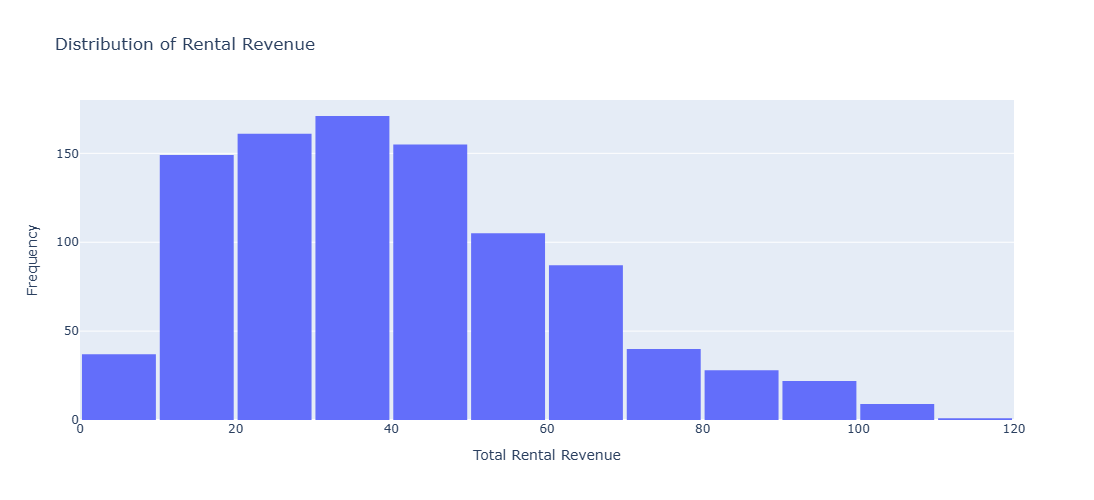

In [61]:
#Distribution Analysis
#Question 9: Using the unified dataset: 
#What is the distribution of:Rental revenue?

fig = px.histogram(
    M1, 
    x='Total Revenue', 
    nbins=20,
    title='Distribution of Rental Revenue',
    labels={'Total Revenue': 'Total Rental Revenue'}
)
fig.update_layout(
    width=800,  
    height=500, 
    yaxis_title='Frequency',
    bargap=0.05  
)
fig.show()



In [62]:
#Distribution Analysis
#Question 9: Using the unified dataset:
#Number of rentals per customer?

Customer_Rentals = (
    master_dataset.groupby('Customer Name')
        .size()
        .reset_index(name='Number Of Rentals')
)

Customer_Rentals.head(10)               



,Customer Name,Number Of Rentals
0,Aaron Selby,24
1,Adam Gooch,22
2,Adrian Clary,19
3,Agnes Bishop,23
4,Alan Kahn,26
5,Albert Crouse,23
6,Alberto Henning,21
7,Alex Gresham,33
8,Alexander Fennell,36
9,Alfred Casillas,26


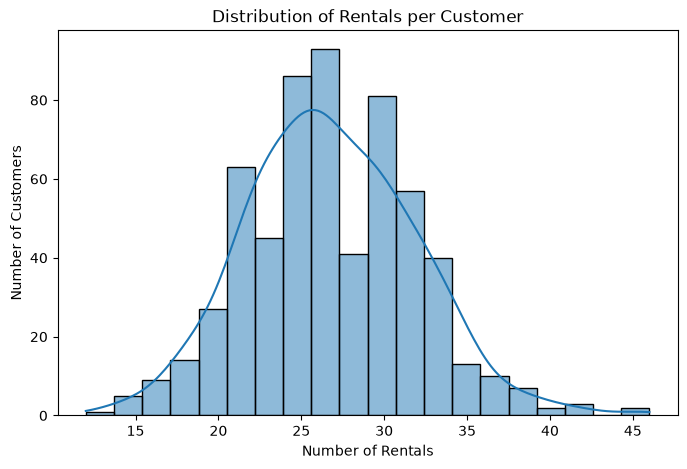

In [63]:
#Distribution Analysis
#Question 9: Using the unified dataset:
#What is the distribution of: Number of rentals per customer?

plt.figure(figsize=(8,5))
sns.histplot(Customer_Rentals["Number Of Rentals"], bins=20, kde=True)

plt.title("Distribution of Rentals per Customer")
plt.xlabel("Number of Rentals")
plt.ylabel("Number of Customers")

plt.show()



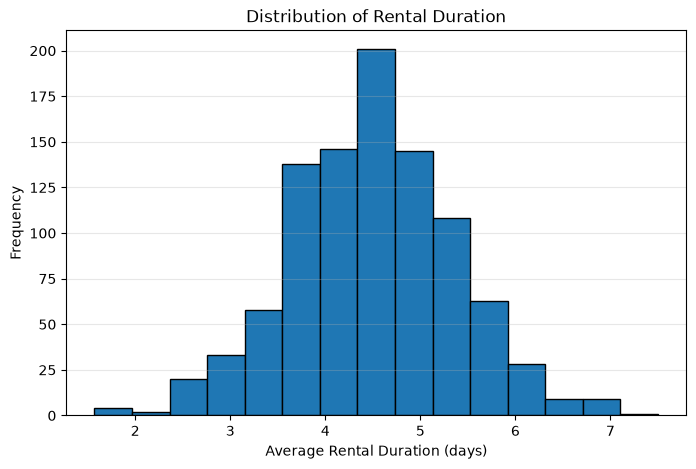

In [64]:
#Distribution Analysis
#Question 9: Using the unified dataset:
#What is the distribution of: Rental duration?


plt.figure(figsize=(8,5))
plt.hist(M1['Average Rental Duration'], bins=15, edgecolor='black')
plt.title('Distribution of Rental Duration')
plt.xlabel('Average Rental Duration (days)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()


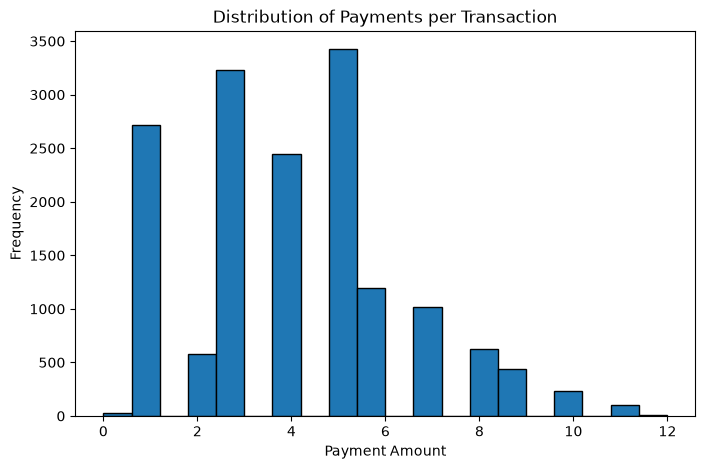

In [65]:
#Distribution Analysis
#Question 9: Using the unified dataset:
#What is the distribution of: Payments per transaction?

plt.figure(figsize=(8,5))
plt.hist(master_dataset['Payment Amount'], bins=20, edgecolor='black')
plt.title('Distribution of Payments per Transaction')
plt.xlabel('Payment Amount')
plt.ylabel('Frequency')
plt.show()


In [66]:
# Question 10: Identify outliers in:
# Revenue

Q1 = M1["Total Revenue"].quantile(0.25)

Q3 = M1["Total Revenue"].quantile(0.75)

IQR = Q3 -Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

# outliers 

outliers = (M1["Total Revenue"] < lower_bound) | (M1["Total Revenue"] > upper_bound)

print(outliers.sum())





10


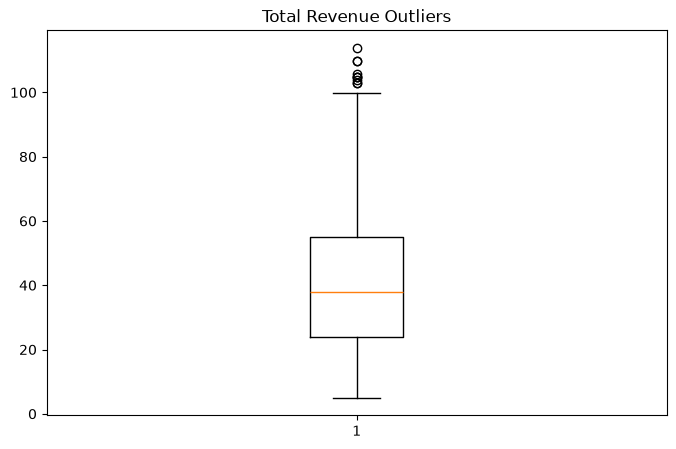

In [67]:
plt.figure(figsize=(8,5))
plt.boxplot(M1['Total Revenue'])
plt.title("Total Revenue Outliers")
plt.show()

In [68]:
# Question 10: Identify outliers in:
# Rentals

Q1 = M1["Total Rentals"].quantile(0.25)

Q3 = M1["Total Rentals"].quantile(0.75)

IQR = Q3 -Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

# outliers 

outliers = (M1["Total Rentals"] < lower_bound) | (M1["Total Rentals"] > upper_bound)

print(outliers.sum())



0


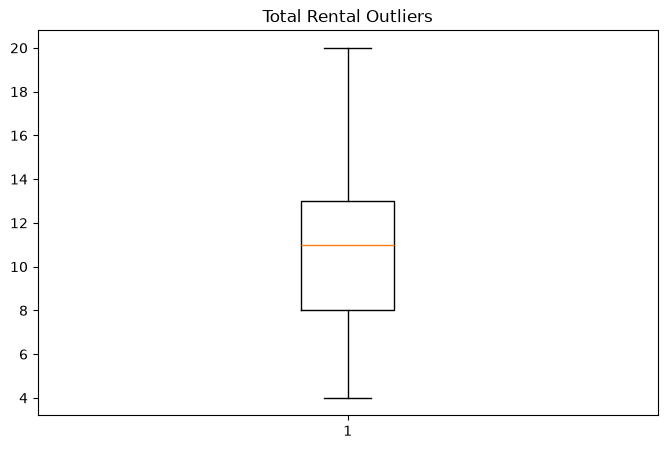

In [69]:
plt.figure(figsize=(8,5))
plt.boxplot(M1['Total Rentals'])
plt.title("Total Rental Outliers")
plt.show()

In [70]:
# Question 10: Identify outliers in:
# Spending per customer => payment amount column 

Q1 = master_dataset["Payment Amount"].quantile(0.25)

Q3 = master_dataset["Payment Amount"].quantile(0.75)

IQR = Q3 -Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR


# outliers 

outliers = (master_dataset["Payment Amount"] < lower_bound) | (master_dataset["Payment Amount"] > upper_bound)

print(outliers.sum())



780


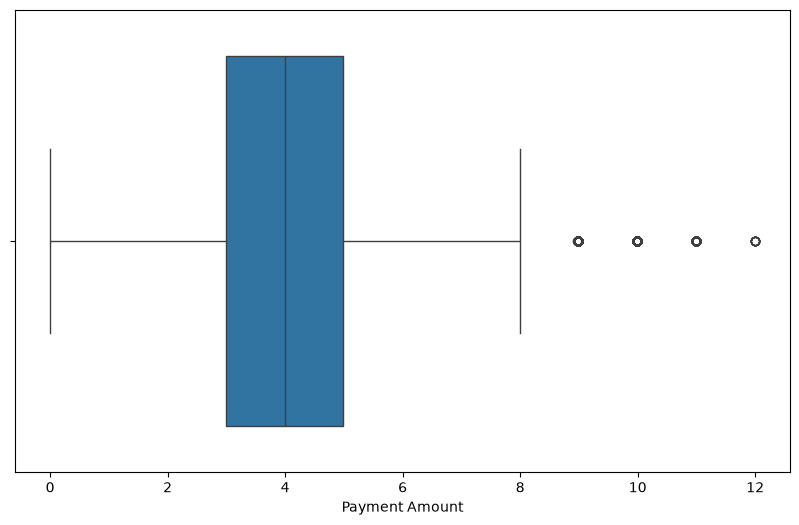

In [71]:
plt.figure(figsize=(10,6))
sns.boxplot(x=master_dataset['Payment Amount'])
plt.show()

In [72]:
# Question 10: Identify outliers in:
# Rental duration

Q1 = master_dataset["Rental Duration"].quantile(0.25)

Q3 = master_dataset["Rental Duration"].quantile(0.75)

IQR = Q3 -Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR


# outliers 

outliers = (master_dataset["Rental Duration"] < lower_bound) | (master_dataset["Rental Duration"] > upper_bound)

print(outliers.sum())





0


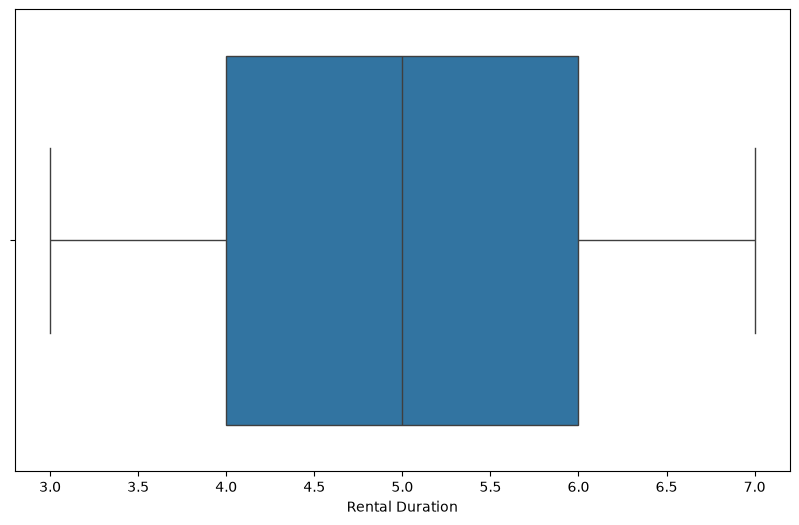

In [73]:
plt.figure(figsize=(10,6))
sns.boxplot(x=master_dataset['Rental Duration'])
plt.show()

In [74]:
# Trend & Pattern Analysis
# 11. How do rentals and revenue change over time?
#monthly rentals and revenue

monthly_trend = (
    M3.groupby('Number Of Rental Months')
      .agg(
          Total_Rentals=('Number Of Rental Months', 'count'),
          Total_Revenue=('Total Amount Spent', 'sum')
      )
      .reset_index()
                )
print("--- Monthly Revenue Trends---")
print(monthly_trend.sort_values(by='Number Of Rental Months'))



--- Monthly Revenue Trends---
   Number Of Rental Months  Total_Rentals  Total_Revenue
0                        2           1248      111940.40
1                        3           9790     1061039.78
2                        4           3554      388280.08


In [75]:


monthly = master_dataset.groupby(
    ["Rental Month Number","Rental Month Name"]
).agg(
    Rentals=("Rental ID","count"),
    Revenue=("Payment Amount","sum")
).sort_values("Rental Month Number")

print(monthly)


                                       Rentals   Revenue
Rental Month Number Rental Month Name                   
2                   February               182    514.18
5                   May                   1156   4612.44
6                   June                  2311   9530.89
7                   July                  6713  28377.87
8                   August                5686  24070.14


In [76]:
# Trend & Pattern Analysis
# 12. Which months perform best and worst?

best_month = monthly["Revenue"].idxmax()
worst_month = monthly["Revenue"].idxmin()

print(monthly.loc[[best_month,worst_month]])

                                       Rentals   Revenue
Rental Month Number Rental Month Name                   
7                   July                  6713  28377.87
2                   February               182    514.18


In [77]:
# Trend & Pattern Analysis
# 13. Which film categories show growth or decline over time?

category_trend = master_dataset.pivot_table(
    index="Rental Month Name",
    columns="Category",
    values="Rental ID",
    aggfunc="count",
    fill_value=0
)

print(category_trend)


Category           Action  Animation  Children  Classics  Comedy  Documentary  \
Rental Month Name                                                               
August                384        408       332       348     342          369   
February               17         21         6         9       9            6   
July                  464        489       406       384     383          429   
June                  160        174       130       136     135          160   
May                    87         74        71        62      72           86   

Category           Drama  Family  Foreign  Games  Horror  Music  New  Sci-Fi  \
Rental Month Name                                                              
August               353     384      377    352     299    277  346     385   
February               7      13       11     14      12     11   13       8   
July                 463     460      432    392     366    348  393     462   
June                 152     154

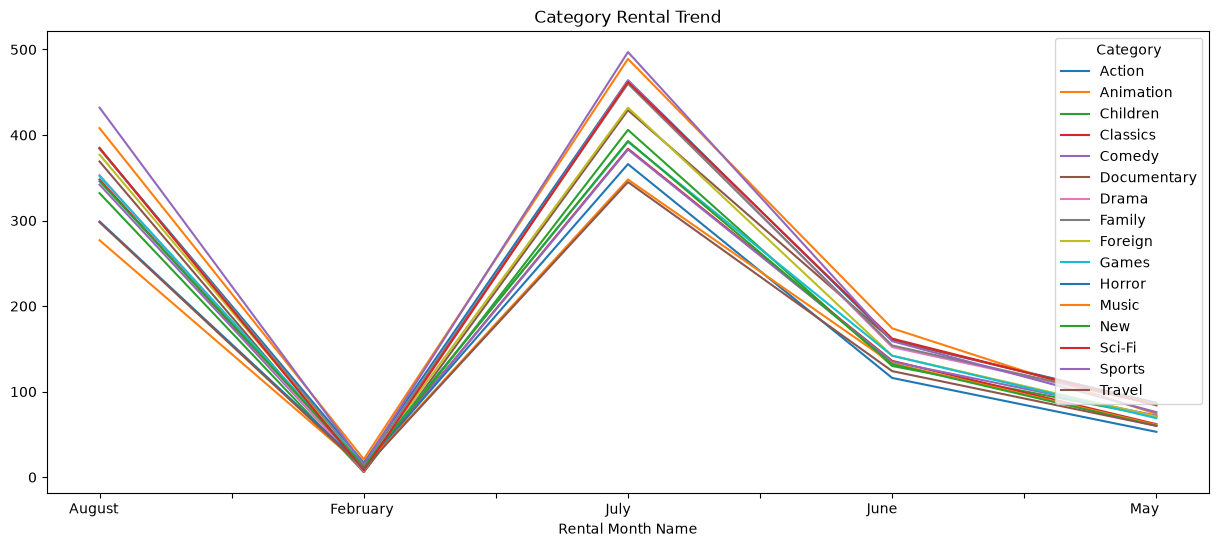

In [78]:
category_trend.plot(figsize=(15,6))
plt.title("Category Rental Trend")
plt.show()

In [79]:
# Trend & Pattern Analysis
# 14. What time of day sees the highest rental activity?

#What time of day sees the highest rental activity?

hourly_activity = (
    master_dataset.groupby('Rental Hour')
      .size()
      .reset_index(name= 'Rental Processed')
      .sort_values(by='Rental Processed', ascending=False)
)
print("\n--- Bussiest Hours of Operation---")
print(hourly_activity.head(10))


--- Bussiest Hours of Operation---
    Rental Hour  Rental Processed
15           15               887
8             8               696
0             0               694
18           18               688
3             3               684
4             4               681
19           19               676
10           10               673
21           21               671
7             7               667


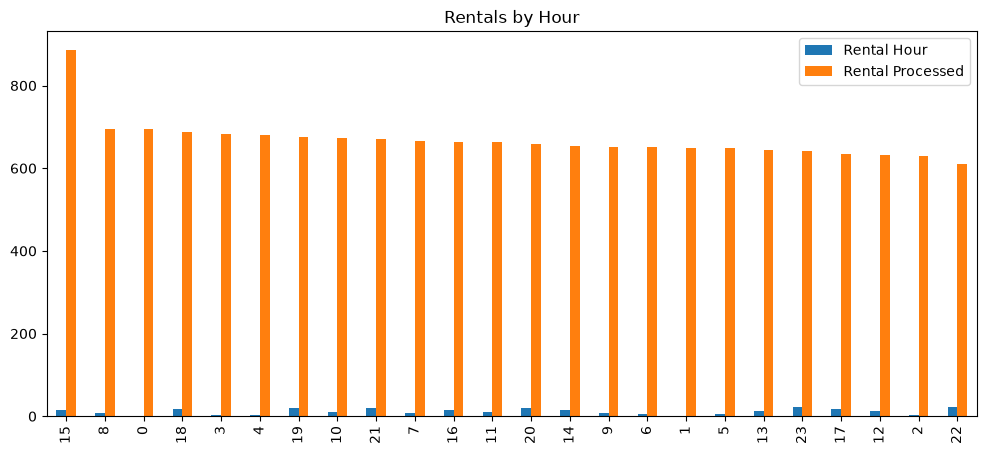

In [80]:
hourly_activity.plot(kind="bar", figsize=(12,5))
plt.title("Rentals by Hour")
plt.show()

In [81]:
# Customer Insights
# 15. What percentage of customers are repeat renters?


customer_rentals = master_dataset.groupby("Customer ID")["Rental ID"].count()

repeat = customer_rentals[customer_rentals>1].count()

total = customer_rentals.count()

repeat_percent = repeat/total*100

print(repeat_percent)

100.0


In [82]:
# Customer Insights
# 16. What is the average spending per customer?


avg_spending = master_dataset.groupby("Customer ID")["Payment Amount"].sum().mean()

print(avg_spending)

112.0292487479132


In [83]:
# Customer Insights
# 17. What is the average time gap between rentals?


master_dataset = master_dataset.sort_values(
    ["Customer ID","Rental Date"]
)

master_dataset["Gap"] = master_dataset.groupby(
    "Customer ID"
)["Rental Date"].diff().dt.days

print(master_dataset["Gap"].mean())


4.659395430124927


In [84]:
# Customer Insights
# 18. How many customers are inactive or at churn risk?


latest = master_dataset["Rental Date"].max()

last_rental = master_dataset.groupby("Customer ID")["Rental Date"].max()

inactive = last_rental[last_rental < latest-pd.Timedelta(days=90)]

print("Inactive Customers:",len(inactive))

Inactive Customers: 441


In [85]:
# Film & Category Insights
# 19.Which films generate the most revenue per rental?

film_rev = master_dataset.groupby("Film Title").agg(
    Revenue=("Payment Amount","sum"),
    Rentals=("Rental ID","count")
)

film_rev["Revenue Per Rental"] = film_rev["Revenue"]/film_rev["Rentals"]

film_rev.sort_values(
    "Revenue Per Rental",
    ascending=False
).head(10)


,Revenue,Rentals,Revenue Per Rental
Film Title,,,
Hustler Party,190.78,22,8.671818
Tycoon Gathering,103.88,12,8.656667
Telegraph Voyage,223.73,27,8.286296
Paths Control,81.90,10,8.190000
Backlash Undefeated,152.81,19,8.042632
Flintstones Happiness,134.83,17,7.931176
Caribbean Liberty,70.91,9,7.878889
Virtual Spoilers,109.86,14,7.847143
Daughter Madigan,69.91,9,7.767778


In [86]:
# Film & Category Insights
# 20. Which categories have the highest average rental price?

category_price = master_dataset.groupby(
    "Category"
)["Payment Amount"].mean().sort_values(ascending=False)

print(category_price)

Category
Comedy         4.635048
New            4.539809
Sports         4.481094
Games          4.397657
Horror         4.364704
Sci-Fi         4.311517
Drama          4.288104
Travel         4.199092
Foreign        4.117783
Music          4.085205
Documentary    4.000495
Animation      3.986535
Action         3.909038
Classics       3.906912
Family         3.887838
Children       3.856667
Name: Payment Amount, dtype: float64


In [87]:
# Film & Category Insights
# 21. Are longer movies rented more or less frequently?


length_analysis = master_dataset.groupby(
    "Film Title"
).agg(
    Length=("length","first"),
    Rentals=("Rental ID","count")
)


print(length_analysis.corr(numeric_only=True))

           Length   Rentals
Length   1.000000 -0.031966
Rentals -0.031966  1.000000


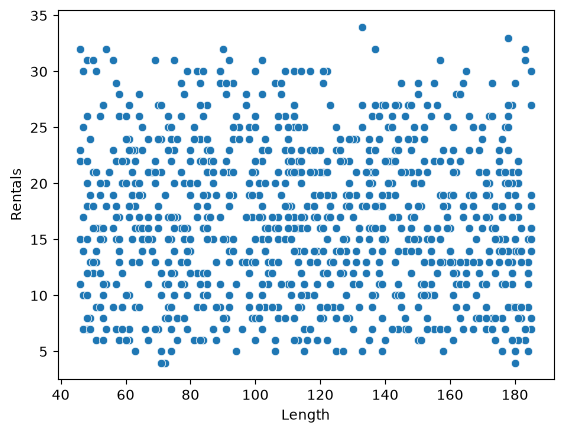

In [88]:
sns.scatterplot(
    data=length_analysis,
    x="Length",
    y="Rentals"
)

plt.show()

In [89]:
# Film & Category Insights
# 22. Which films have high demand but low inventory?

inventory = master_dataset.groupby(
    "Film Title"
).agg(
    Rentals=("Rental ID","count"),
    Inventory=("Inventory ID","nunique")
)

inventory["Demand Ratio"] = inventory["Rentals"]/inventory["Inventory"]

inventory.sort_values(
    "Demand Ratio",
    ascending=False
).head(20)

,Rentals,Inventory,Demand Ratio
Film Title,,,
Jungle Closer,13,2,6.50
Halloween Nuts,10,2,5.00
Gone Trouble,10,2,5.00
Anthem Luke,15,3,5.00
Shrek License,15,3,5.00
Antitrust Tomatoes,10,2,5.00
Hollow Jeopardy,10,2,5.00
Sweet Brotherhood,15,3,5.00
Mystic Truman,10,2,5.00


In [90]:
# Store & Staff Insights
# 23.Which store is more profitable?

store = master_dataset.groupby("Customer Store ID").agg(
    Revenue=("Payment Amount","sum"),
    Rentals=("Rental ID","count")
)

print(store)


                    Revenue  Rentals
Customer Store ID                   
1                  36778.49     8751
2                  30327.03     7297


In [91]:
# Store & Staff Insights
# 24. Which staff member is the most efficient?

staff = master_dataset.groupby(
    ["Staff ID","Staff Name"]
).agg(
    Revenue=("Payment Amount","sum"),
    Rentals=("Rental ID","count"),
    Customers=("Customer ID","nunique")
)

print(staff.sort_values("Revenue",ascending=False))


                        Revenue  Rentals  Customers
Staff ID Staff Name                                
2        Jon Stephens  33761.94     8004        599
1        Mike Hillyer  33343.58     8044        599


In [92]:
# Store & Staff Insights
# 25. What staffing patterns correlate with higher revenue?

staff_pattern = master_dataset.groupby(
    ["Rental Hour","Staff Name"]
).agg(
    Revenue=("Payment Amount","sum"),
    Rentals=("Rental ID","count")
)

print(staff_pattern)

                          Revenue  Rentals
Rental Hour Staff Name                    
0           Jon Stephens  1446.46      354
            Mike Hillyer  1385.60      340
1           Jon Stephens  1309.74      326
            Mike Hillyer  1252.77      323
2           Jon Stephens  1312.75      325
            Mike Hillyer  1214.95      305
3           Jon Stephens  1428.51      349
            Mike Hillyer  1369.65      335
4           Jon Stephens  1466.66      334
            Mike Hillyer  1435.53      347
5           Jon Stephens  1350.79      321
            Mike Hillyer  1401.73      327
6           Jon Stephens  1346.83      317
            Mike Hillyer  1444.66      334
7           Jon Stephens  1348.81      319
            Mike Hillyer  1445.52      348
8           Jon Stephens  1475.40      360
            Mike Hillyer  1363.64      336
9           Jon Stephens  1402.73      327
            Mike Hillyer  1369.75      325
10          Jon Stephens  1259.07      293
           

In [93]:
# Geographic Insights
# 26. Which countries are the most profitable?


country = master_dataset.groupby("Country").agg(
    Revenue=("Payment Amount","sum"),
    Rentals=("Rental ID","count")
).sort_values("Revenue",ascending=False)

print(country)

                Revenue  Rentals
Country                         
India           6635.28     1572
China           5765.74     1426
United States   4089.28      972
Japan           3428.75      825
Mexico          3296.04      796
...                 ...      ...
Tunisia           77.77       23
Tonga             72.82       18
Lithuania         71.76       24
Afghanistan       67.82       18
American Samoa    67.80       20

[108 rows x 2 columns]


In [94]:
# Geographic Insights
# 26. Which cities are the most profitable?

city = master_dataset.groupby("City").agg(
    Revenue=("Payment Amount","sum"),
    Rentals=("Rental ID","count")
).sort_values("Revenue",ascending=False)

print(city)

                     Revenue  Rentals
City                                 
Cape Coral            220.55       45
Saint-Denis           215.54       46
Molodetno             197.58       42
Apeldoorn             195.61       39
Santa Brbara dOeste   194.61       39
...                      ...      ...
Enshi                  57.86       14
al-Qadarif             57.81       19
Fuzhou                 48.86       14
Bydgoszcz              47.88       12
Tallahassee            45.85       15

[597 rows x 2 columns]


In [95]:
# Geographic Insights
# 27. Do customer preferences differ by region?

preferences = master_dataset.pivot_table(
    index="Country",
    columns="Category",
    values="Rental ID",
    aggfunc="count",
    fill_value=0
)

print(preferences)


Category              Action  Animation  Children  Classics  Comedy  \
Country                                                               
Afghanistan                1          1         1         2       3   
Algeria                    5          7         7         3       8   
American Samoa             1          1         1         1       2   
Angola                     3          7         5         4       7   
Anguilla                   1          4         3         2       1   
...                      ...        ...       ...       ...     ...   
Vietnam                   12          9         7        13      14   
Virgin Islands, U.S.       1          7         2         3       3   
Yemen                     15          5        11         3       4   
Yugoslavia                 3          7         4         1       2   
Zambia                     2          4         1         2       3   

Category              Documentary  Drama  Family  Foreign  Games  Horror  \


In [96]:
# Geographic Insights
# 28. Which regions show the fastest growth?


growth = master_dataset.groupby(
    ["Country","Rental Month Number"]
)["Payment Amount"].sum().reset_index()

print(growth)

         Country  Rental Month Number  Payment Amount
0    Afghanistan                    6            4.97
1    Afghanistan                    7           37.92
2    Afghanistan                    8           24.93
3        Algeria                    2            5.98
4        Algeria                    5           31.92
..           ...                  ...             ...
479       Zambia                    2            0.99
480       Zambia                    5           11.97
481       Zambia                    6           17.94
482       Zambia                    7           54.86
483       Zambia                    8           47.91

[484 rows x 3 columns]


In [97]:
# Validation & Data Quality Checks
# 29. Do totals from the unified dataset match totals from original SQL outputs?

print(master_dataset["Payment Amount"].sum())

print(master_dataset["Rental ID"].nunique())


67105.51999999999
16044


In [98]:
# Validation & Data Quality Checks
# 30. Are revenue and rental counts consistent across time, geography, and film dimensions?


time_check = master_dataset.groupby("Rental Month Name").agg(
    Revenue=("Payment Amount","sum"),
    Rentals=("Rental ID","count")
)

country_check = master_dataset.groupby("Country").agg(
    Revenue=("Payment Amount","sum"),
    Rentals=("Rental ID","count")
)

film_check = master_dataset.groupby("Category").agg(
    Revenue=("Payment Amount","sum"),
    Rentals=("Rental ID","count")
)

print(time_check)
print(country_check)
print(film_check)



                    Revenue  Rentals
Rental Month Name                   
August             24070.14     5686
February             514.18      182
July               28377.87     6713
June                9530.89     2311
May                 4612.44     1156
                      Revenue  Rentals
Country                               
Afghanistan             67.82       18
Algeria                381.10       90
American Samoa          67.80       20
Angola                 215.48       52
Anguilla               111.65       35
...                       ...      ...
Vietnam                744.28      172
Virgin Islands, U.S.   125.68       32
Yemen                  513.83      117
Yugoslavia             257.43       57
Zambia                 133.67       33

[108 rows x 2 columns]
             Revenue  Rentals
Category                     
Action       4346.85     1112
Animation    4648.30     1166
Children     3644.55      945
Classics     3668.59      939
Comedy       4361.58      941


In [99]:
# Validation & Data Quality Checks

# 31. Are any records missing critical identifiers (film, customer, date)?


missing = master_dataset[
    [
        "Rental ID",
        "Customer ID",
        "Film ID",
        "Rental Date"
    ]
].isnull().sum()

print(missing)

Rental ID      0
Customer ID    0
Film ID        0
Rental Date    0
dtype: int64


In [100]:
master_dataset.isnull().sum()

Rental ID                0
Inventory ID             0
Inventory Store ID       0
Rental Date              0
Rental Month Number      0
Rental Month Name        0
Rental Hour              0
Total Rentals            0
Customer ID              0
Customer Name            0
City                     0
Country                  0
Film ID                  0
Film Title               0
Category                 0
length                   0
Customer Store ID        0
Staff ID                 0
Staff Name               0
Payment Amount           0
Payment Date             0
Rental Duration          0
Gap                    599
dtype: int64

In [101]:
#conversion of the master dataset to csv and save it under data

master_dataset.to_csv('data/cleaned_master_dataset.csv', index=False)